# Tests Complets pour l'Implémentation FCI

Ce notebook contient tous les tests nécessaires pour évaluer l'algorithme FCI selon les critères du projet MADI:
- Tests sur données simulées
- Comparaison avec MIIC (pyAgrum)
- Analyse de structure et complexité computationnelle

## 1. Installation et Imports

In [1]:
!pip install pyagrum numpy pandas graphviz matplotlib seaborn

In [2]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import bnlearn as bn
import pgmpy
import graphviz
import numpy as np
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz, gsq
from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image, display

mr = gum.MeekRules()

In [3]:
%load_ext autoreload
%autoreload 2

from FCI import *
import utils

## 2. Test 1 - Réseau Bayésien Simple 

Test 1: Réseau simple (4 variables)
------------------------------------------------------------
Réseau créé: 5 variables, 6 arcs


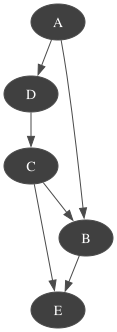

In [4]:
# Création d'un réseau bayésien simple avec une structure connue
print("Test 1: Réseau simple (4 variables)")
print("-" * 60)

bn_simple = gum.BayesNet("Simple_Network")

a = bn_simple.add(gum.LabelizedVariable('A', 'Variable A', 2))
b = bn_simple.add(gum.LabelizedVariable('B', 'Variable B', 2))
c = bn_simple.add(gum.LabelizedVariable('C', 'Variable C', 2))
d = bn_simple.add(gum.LabelizedVariable('D', 'Variable D', 2))
e = bn_simple.add(gum.LabelizedVariable('E', 'Variable E', 2))


bn_simple.addArc(a, b)
bn_simple.addArc(a, d)
bn_simple.addArc(b, e)
bn_simple.addArc(c, b)
bn_simple.addArc(c, e)
bn_simple.addArc(d, c)


bn_simple.generateCPTs()

print(f"Réseau créé: {bn_simple.size()} variables, {bn_simple.sizeArcs()} arcs")

# Visualisation
gnb.showBN(bn_simple)

In [77]:
# Génération des données
df_simple,_ = utils.generate_test_data(bn_simple, n_samples=1000)
print(f"Données générées: {len(df_simple)} échantillons")
print(f"\nAperçu des données:")
latent_var = (3,df_simple.columns[3])
df_simple = df_simple.drop(columns=latent_var[1])
print(latent_var)
df_simple.head()

Données générées: 1000 échantillons

Aperçu des données:
(3, 'D')


,A,B,C,E
0,1,1,0,0
1,1,1,1,0
2,1,0,1,1
3,0,0,1,1
4,0,1,1,0


Exécution de FCI...
FCI terminé en 0.014s

PAG résultant (FCI):


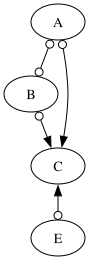

In [78]:
# Test FCI
print("Exécution de FCI...")
fci_simple, fci_time_simple = utils.measure_execution_time(run_FCI, df_simple, alpha=0.05, useGum=True)
print(f"FCI terminé en {fci_time_simple:.3f}s")

# Visualisation du résultat FCI
print("\nPAG résultant (FCI):")
# print(fci_simple.get_variables())
fci_simple.toDot()

Exécution de MIIC...
MIIC terminé en 0.000s

PDAG résultant (MIIC):


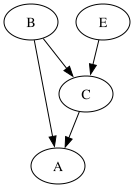

In [88]:
# Test MIIC
print("Exécution de MIIC...")
learner_simple = gum.BNLearner(df_simple)

def run_miic(learner):
    learner.useMIIC()
    return learner.learnPDAG()

miic_simple, miic_time_simple = utils.measure_execution_time(run_miic, learner_simple)
print(f"MIIC terminé en {miic_time_simple:.3f}s")

# Visualisation du résultat MIIC
print("\nPDAG résultant (MIIC):")
utils.labelize_pdag_nodes(miic_simple, bn_simple, latent_var)

In [90]:
comparison = utils.compare_structures(fci_simple, miic_simple, bn_simple)
utils.print_comparison_results(comparison, fci_time_simple, miic_time_simple)

FCI {0: 'A', 1: 'B', 2: 'C', 3: 'E'}
BN {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
------------------------------------------------------------
COMPARAISON FCI vs MIIC
------------------------------------------------------------
Structure:
  FCI  - Total arêtes squelette: 4
       - Orientées: 3
       - Non-orientées: 1
  MIIC - Total arêtes squelette : 4
       - Arcs: 4

Similarité:
  Arêtes communes: 1
  Jaccard similarity: 0.143

Temps d'exécution:
  FCI:  0.014s
  MIIC: 0.000s
  Ratio (FCI/MIIC): 34.41x


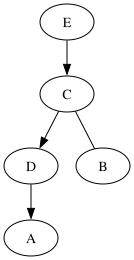

In [29]:
graph = fci_simple.return_PDAG(opt=1)
utils.labelize_pdag_nodes(graph, fci_simple)

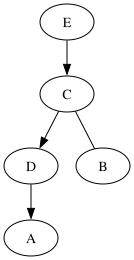

In [30]:
graph = fci_simple.return_PDAG(opt=2)
utils.labelize_pdag_nodes(graph, fci_simple)

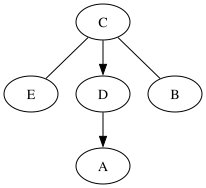

In [31]:
graph = fci_simple.return_PDAG(opt=3)
utils.labelize_pdag_nodes(graph, fci_simple)

## Analyse de Scalabilité

In [ ]:
# Test de scalabilité: temps d'exécution en fonction du nombre de variables
print("📝 Test : Analyse de scalabilité")
print("-" * 60)

n_vars_list = [4, 6, 8, 10, 12, 14]
fci_times = []
rfci_times = []
miic_times = []
n_edges_fci = []
n_edges_miic = []

for n in n_vars_list:
    print(f"\nTest avec {n} variables...")
    
    # Création du réseau
    bn_test = gum.randomBN(n=n, names=[f'X{i}' for i in range(n)])
    bn_test.generateCPTs()
    
    # Génération des données
    df_test,_ = utils.generate_test_data(bn_test, n_samples=1000)
    df_test.drop(columns=df_test.columns[-1])
    
    # FCI
    fci_result, t_fci = utils.measure_execution_time(run_FCI, df_test, alpha=0.05, useGum=True, bayesnet=bn_test)
    fci_times.append(t_fci)
    
    # RFCI
    # rfci_result, t_rfci = utils.measure_execution_time(run_RFCI, df_test, alpha=0.05, useGum=True, bayesnet=bn_test)
    # rfci_times.append(t_rfci)
    
    # MIIC
    learner_test = gum.BNLearner(df_test, bn_test)
    miic_result, t_miic = utils.measure_execution_time(run_miic, learner_test)
    miic_times.append(t_miic)

    comparison = utils.compare_structures(fci_result, miic_result, bn_test)
    utils.print_comparison_results(comparison, t_fci, t_miic)

📝 Test : Analyse de scalabilité
------------------------------------------------------------

Test avec 4 variables...
------------------------------------------------------------
COMPARAISON FCI vs MIIC
------------------------------------------------------------
Structure:
  FCI  - Total arêtes squelette: 3
       - Orientées: 0
       - Non-orientées: 0
  MIIC - Total arêtes squelette : 3
       - Arcs: 0

Similarité:
  Arêtes communes: 2
  Jaccard similarity: 0.500

Temps d'exécution:
  FCI:  0.004s
  MIIC: 0.001s
  Ratio (FCI/MIIC): 4.71x

Test avec 6 variables...
------------------------------------------------------------
COMPARAISON FCI vs MIIC
------------------------------------------------------------
Structure:
  FCI  - Total arêtes squelette: 4
       - Orientées: 2
       - Non-orientées: 0
  MIIC - Total arêtes squelette : 5
       - Arcs: 3

Similarité:
  Arêtes communes: 3
  Jaccard similarity: 0.500

Temps d'exécution:
  FCI:  0.005s
  MIIC: 0.001s
  Ratio (FCI/MIIC):